In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Copy of GSS2.csv')           

In [3]:
df.head()

,year,id_,wrkstat,hrs2,age,sex,region,happy,hapmar
0,1972,1,Working full time,.i: Inapplicable,23,FEMALE,Midwest,Not too happy,.i: Inapplicable
1,1972,2,Retired,.i: Inapplicable,70,MALE,Midwest,Not too happy,.i: Inapplicable
2,1972,3,Working part time,.i: Inapplicable,48,FEMALE,Midwest,Pretty happy,.i: Inapplicable
3,1972,4,Working full time,.i: Inapplicable,27,FEMALE,Midwest,Not too happy,.i: Inapplicable
4,1972,5,Keeping house,.i: Inapplicable,61,FEMALE,Midwest,Pretty happy,.i: Inapplicable


In [4]:
df = df.drop('hrs2', axis = 1)

In [5]:
df = df.drop('id_', axis = 1)

In [6]:
df.hapmar.value_counts()

hapmar
.i:  Inapplicable                 40079
VERY HAPPY                        22229
PRETTY HAPPY                      12010
NOT TOO HAPPY                      1111
.n:  No answer                      197
.d:  Do not Know/Cannot Choose       53
.s:  Skipped on Web                  20
Name: count, dtype: int64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

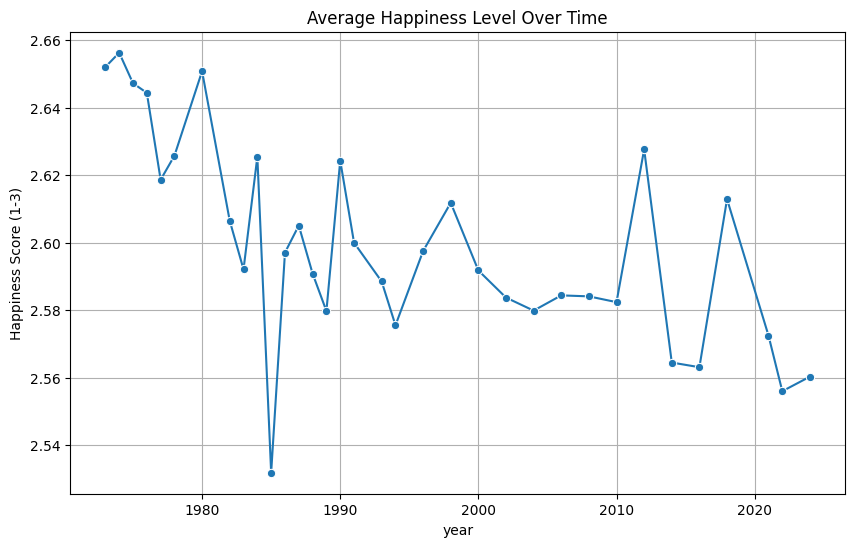

In [8]:
happiness_map = {
    'NOT TOO HAPPY': 1,
    'PRETTY HAPPY': 2,
    'VERY HAPPY': 3
}
df['happy_numeric'] = df['hapmar'].map(happiness_map)

# 2. Group by year and calculate the mean
annual_happiness = df.groupby('year')['happy_numeric'].mean().reset_index()

# 3. Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=annual_happiness, x='year', y='happy_numeric', marker='o')
plt.title('Average Happiness Level Over Time')
plt.ylabel('Happiness Score (1-3)')
plt.grid(True)
plt.show()

## Kinda Decieving, Marriage clearly increases happiness, and has been (relatively) stable over time. 

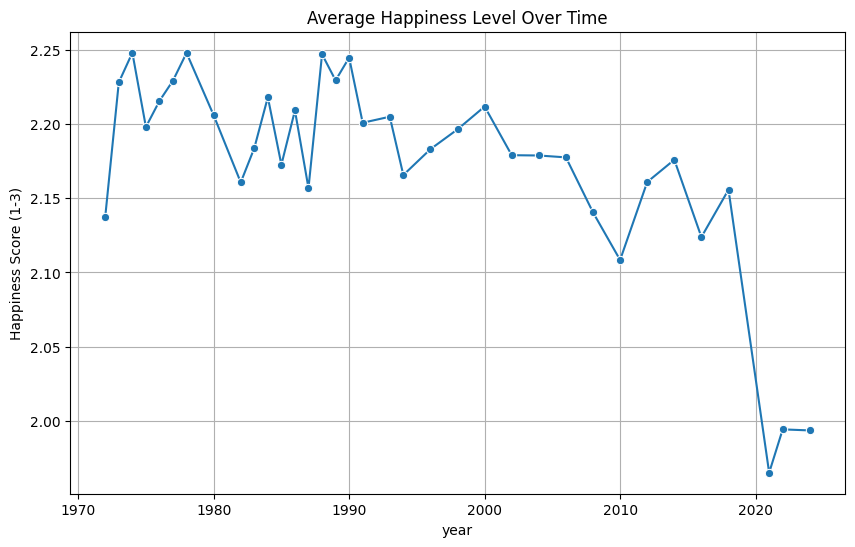

In [9]:
# 1. Map labels to numbers
happiness_map = {
    'Not too happy': 1,
    'Pretty happy': 2,
    'Very happy': 3
}
df['happy_numeric'] = df['happy'].map(happiness_map)

# 2. Group by year and calculate the mean
annual_happiness = df.groupby('year')['happy_numeric'].mean().reset_index()

# 3. Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=annual_happiness, x='year', y='happy_numeric', marker='o')
plt.title('Average Happiness Level Over Time')
plt.ylabel('Happiness Score (1-3)')
plt.grid(True)
plt.show()

## Happiness seems to have dropped a not insignificant amount after 2020

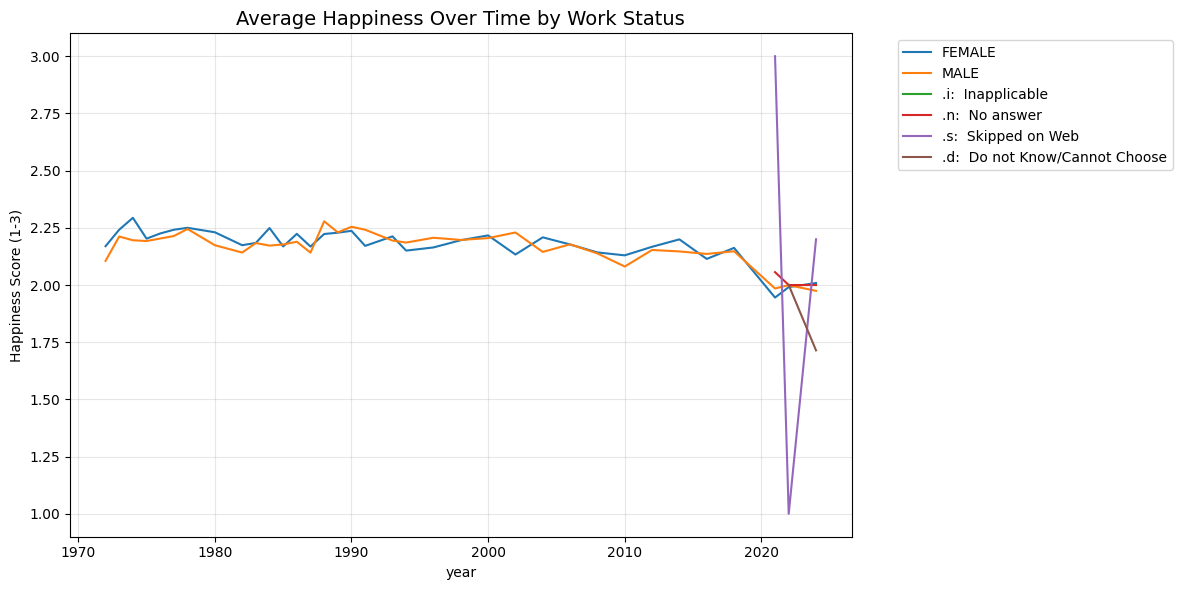

In [10]:

# 1. Map happiness to a numeric scale
happiness_map = {'Not too happy': 1, 'Pretty happy': 2, 'Very happy': 3}
df['happy_numeric'] = df['happy'].map(happiness_map)

clean_df = df.dropna(subset=['happy_numeric', 'sex'])

# 3. Group by year and work status
wrk_trends = clean_df.groupby(['year', 'sex'])['happy_numeric'].mean().reset_index()

# 4. Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=wrk_trends, x='year', y='happy_numeric', hue='sex')

plt.title('Average Happiness Over Time by Work Status', fontsize=14)
plt.ylabel('Happiness Score (1-3)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## There seems to be no difference in happiness rates between males and female

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75699 entries, 0 to 75698
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           75699 non-null  int64  
 1   wrkstat        75699 non-null  object 
 2   age            75699 non-null  object 
 3   sex            75699 non-null  object 
 4   region         75699 non-null  object 
 5   happy          75699 non-null  object 
 6   hapmar         75699 non-null  object 
 7   happy_numeric  70869 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 4.6+ MB


In [12]:
import pandas as pd

# 1. Convert the column to numeric. Non-numbers become NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# 2. Drop the rows that became NaN
df = df.dropna(subset=['age'])

C:\Users\USER\AppData\Local\Temp\ipykernel_14184\3274513488.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_trends = df.groupby(['year', 'age_group'])['happy_numeric'].mean().reset_index()


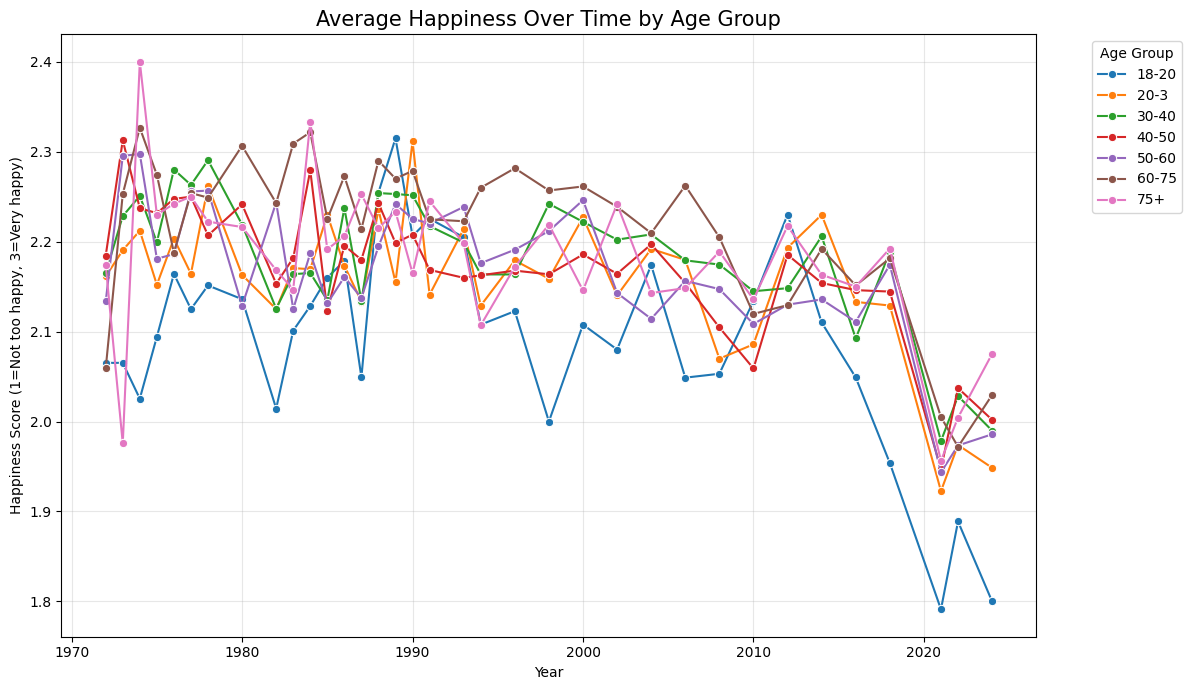

In [15]:
# 1. Clean data: Remove "Inapplicable" or missing responses
df = df[~df['happy'].astype(str).str.contains('Inapplicable', na=False)]

# 2. Map happiness to a numeric scale (The "Index")
happiness_map = {'Not too happy': 1, 'Pretty happy': 2, 'Very happy': 3}
df['happy_numeric'] = df['happy'].map(happiness_map)

# 3. Create Age Groups (Bins)
# This assumes you have a column named 'age'
bins = [17, 22, 30, 40, 50, 60, 75, 120]
labels = ['18-20', '20-3', '30-40', '40-50','50-60','60-75','75+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# 4. Group by year AND age group
age_trends = df.groupby(['year', 'age_group'])['happy_numeric'].mean().reset_index()

# 5. Plot with 'hue' to separate the lines
plt.figure(figsize=(12, 7))
sns.lineplot(data=age_trends, x='year', y='happy_numeric', hue='age_group', marker='o')

plt.title('Average Happiness Over Time by Age Group', fontsize=15)
plt.ylabel('Happiness Score (1=Not too happy, 3=Very happy)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## happiness rates are semi stable by age, although it is worth noting that older people are generally happier, and also that in the past decade or younger people seem to be having a harder time

C:\Users\USER\AppData\Local\Temp\ipykernel_14184\3260218179.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trends = df.groupby(['year', 'age_group', 'sex'])['happy_numeric'].mean().reset_index()


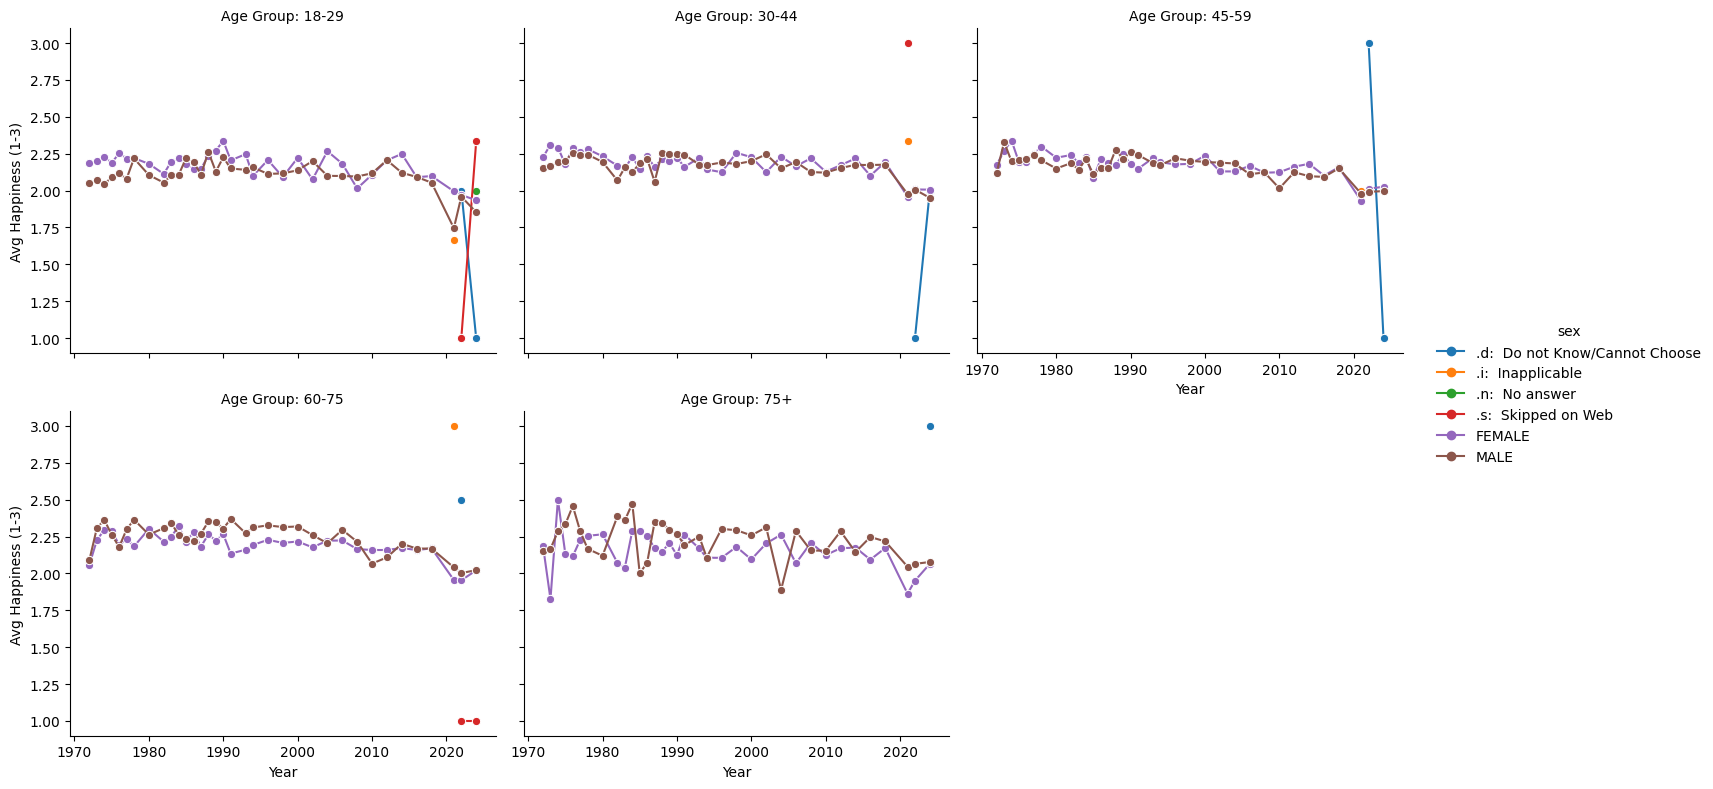

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean data and Map Happiness
df = df[~df['happy'].astype(str).str.contains('Inapplicable', na=False)]
happiness_map = {'Not too happy': 1, 'Pretty happy': 2, 'Very happy': 3}
df['happy_numeric'] = df['happy'].map(happiness_map)

# 2. Create Age Groups
bins = [17, 29, 44, 59, 75, 120]
labels = ['18-29', '30-44', '45-59', '60-75', '75+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# 3. Group by Year, Age Group, AND Sex
# Note: Ensure your column is named 'sex' or 'SEX' based on your dataset
trends = df.groupby(['year', 'age_group', 'sex'])['happy_numeric'].mean().reset_index()

# 4. Create a Faceted Plot
g = sns.relplot(
    data=trends, 
    x='year', 
    y='happy_numeric', 
    hue='sex', 
    col='age_group', 
    col_wrap=3,       # Sets 3 charts per row
    kind='line', 
    marker='o',
    height=4, 
    aspect=1.2
)

# 5. Formatting
g.set_axis_labels("Year", "Avg Happiness (1-3)")
g.set_titles("Age Group: {col_name}")
g.tight_layout()

plt.show()

## It seems to be relatively stable. We still havent figured out, WHY did happiness rates decline so much (and have continued at a lower levle??). 

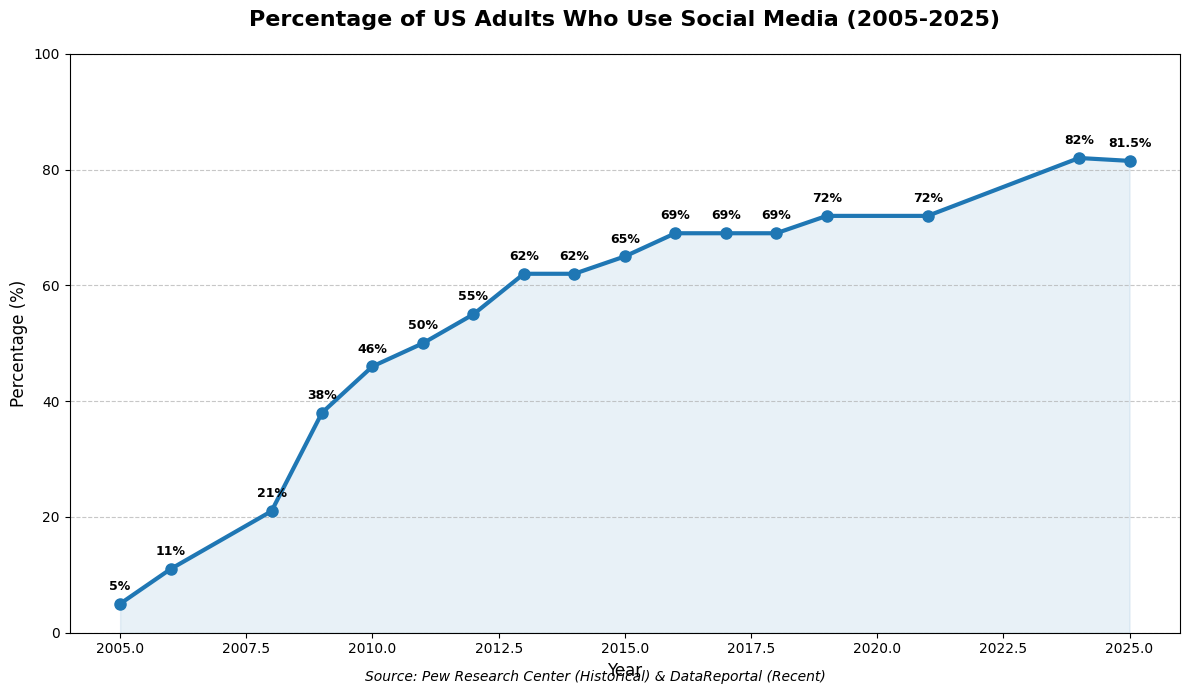

In [16]:
import matplotlib.pyplot as plt

# Data Source: Pew Research Center (2005-2021) & DataReportal (2024-2025)
# Note: 2020, 2022, 2023 are omitted where specific major survey data points were not standardized.
years = [2005, 2006, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2024, 2025]
usage_percentages = [5, 11, 21, 38, 46, 50, 55, 62, 62, 65, 69, 69, 69, 72, 72, 82, 81.5]

# Create the figure and axis
plt.figure(figsize=(12, 7))

# Plot the line chart
plt.plot(years, usage_percentages, color='#1f77b4', marker='o', linewidth=3, markersize=8)

# Fill area under the line for better visualization
plt.fill_between(years, usage_percentages, color='#1f77b4', alpha=0.1)

# Add titles and labels
plt.title('Percentage of US Adults Who Use Social Media (2005-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Set Y-axis range from 0 to 100
plt.ylim(0, 100)
plt.xlim(2004, 2026)

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each data point with its percentage
for x, y in zip(years, usage_percentages):
    label = f"{y}%"
    plt.annotate(
        label, 
        (x, y), 
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center', 
        fontsize=9, 
        fontweight='bold'
    )

# Add source footer
plt.figtext(0.5, 0.02, "Source: Pew Research Center (Historical) & DataReportal (Recent)", ha="center", fontsize=10, style='italic')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()